# Mapping Change and Uncertainty: A Spatial Analysis of Connecticut Communities


For the mid. term, I had you all look at merging interesting datasets from CTData together. Many chose something related to demographics, income, education etc. Now I want you to revist that first project and identify if there was something missing... perhaps a closer look at UNCERTAINTY and resampling!

# Overview

This project explores demographic and socioeconomic trends across Connecticut towns using geospatial analysis. Three datasets from the Connecticut Data Collaborative are joined to town-level shapefiles to visualize how key variables — such as educational attainment, english proficiency, and single mother households — have changed over time.

# Data sources:

**Town-level datasets** - https://github.com/orgs/CT-Data-Collaborative/repositories

**Connecticut town boundaries** - https://ct-deep-gis-open-data-website-ctdeep.hub.arcgis.com/datasets/CTDEEP::connecticut-towns-set/explore?layer=1&location=41.497268%2C-72.761769%2C8.45

**For county-resolution comparison** - https://www2.census.gov/geo/tiger/TIGER2019/COUSUB/tl_2019_09_cousub.zip

# Approach:

The three chosen datasets were reshaped from long to wide format and joined to Connecticut's 169 towns, resulting in a clean, well-labeled geodataframe. One variable from each dataset was selected to tell a story about change over time, with actual, low-estimate, and high-estimate values (calculated using margin of error) plotted for both the oldest and newest available time steps.

Each map includes a caption describing the observed spatial patterns, and a broader discussion section examines how these variables shifted across Connecticut over time, along with where uncertainty was greatest.

To add a regional perspective, one variable was resampled from town to county resolution, aggregating values by county and mapping them for both the earliest and latest time steps with a consistent color scale for direct comparison.

# Design considerations:

Care was taken throughout to ensure plots are clearly labeled with legends and axis titles, using consistent color ramps and fixed vmin/vmax values so that visual comparisons across maps are meaningful and accurate.

# 1. Data Cleaning (long to wide)


In [ ]:
# Load the three datasets
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

educ_url = "https://drive.google.com/uc?id=1kAUphDcuxZT6DQceuBWqWVWmkdt_kv-R"
english_url = "https://drive.google.com/uc?id=10USyklfhTKi3FiYsQ3_gFZd305UZF8sq"
children_url = "https://drive.google.com/uc?id=1IPe0nnGDaYxghHingymcQhdcHt7JNtpu"

educ = pd.read_csv(educ_url)
english = pd.read_csv(english_url)
children = pd.read_csv(children_url)


In [ ]:
# Inspect each dataset
print(educ.columns)
print(english.columns)
print(children.columns)


Index(['Year', 'GeoID', 'Geography Type', 'Geography Name', 'Sex', 'Education',
       'Value', 'Margin of Error', 'Measure', 'ObjectId'],
      dtype='object')
Index(['Year', 'GeoID', 'Geography Type', 'Geography Name', 'Proficiency',
       'Age', 'Value', 'Margin of Error', 'Measure', 'ObjectId'],
      dtype='object')
Index(['Year', 'GeoID', 'Geography Type', 'Geography Name', 'Family Type',
       'Value', 'Margin of Error', 'Measure', 'ObjectId'],
      dtype='object')


In [ ]:
# STEP 3 — Convert LONG → WIDE for each dataset
# Rename "Geography Name" → "Town" in all three datasets
educ.rename(columns={"Geography Name": "Town"}, inplace=True)
english.rename(columns={"Geography Name": "Town"}, inplace=True)
children.rename(columns={"Geography Name": "Town"}, inplace=True)


In [ ]:
# OLDEST YEAR
oldest_year = educ["Year"].min()

educ_old = educ[educ["Year"] == oldest_year]
english_old = english[english["Year"] == oldest_year]
children_old = children[children["Year"] == oldest_year]


In [ ]:
# NEWEST YEAR
newest_year = educ["Year"].max()

educ_new = educ[educ["Year"] == newest_year]
english_new = english[english["Year"] == newest_year]
children_new = children[children["Year"] == newest_year]


In [ ]:
# EDUCATION (Old) Dataset Pivot (uses 'Education' as variable column)
educ_old_wide = educ_old.pivot_table(
    index="Town",
    columns="Education",
    values=["Value", "Margin of Error"],
    aggfunc="mean"
).reset_index()

educ_old_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col
                         for col in educ_old_wide.columns]


In [ ]:
# EDUCATION (New)
educ_new_wide = educ_new.pivot_table(
    index="Town",
    columns="Education",
    values=["Value", "Margin of Error"],
    aggfunc="mean"
).reset_index()

educ_new_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col
                         for col in educ_new_wide.columns]


In [ ]:
# ENGLISH (Old) Dataset Pivot (uses 'Proficiency' as variable column)
english_old_wide = english_old.pivot_table(
    index="Town",
    columns="Proficiency",
    values=["Value", "Margin of Error"],
    aggfunc="mean"
).reset_index()

english_old_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col
                            for col in english_old_wide.columns]


In [ ]:
# ENGLISH (New)
english_new_wide = english_new.pivot_table(
    index="Town",
    columns="Proficiency",
    values=["Value", "Margin of Error"],
    aggfunc="mean"
).reset_index()

english_new_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col
                            for col in english_new_wide.columns]


In [ ]:
# CHILDREN (Old) Dataset Pivot (uses 'Family Type' as variable column)
children_old_wide = children_old.pivot_table(
    index="Town",
    columns="Family Type",
    values=["Value", "Margin of Error"],
    aggfunc="mean"
).reset_index()

children_old_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col
                             for col in children_old_wide.columns]


In [ ]:
# CHILDREN (New)
children_new_wide = children_new.pivot_table(
    index="Town",
    columns="Family Type",
    values=["Value", "Margin of Error"],
    aggfunc="mean"
).reset_index()

children_new_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col
                             for col in children_new_wide.columns]


In [ ]:
print(educ["Year"].unique())

oldest_year = educ["Year"].min()

[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]


In [ ]:
# OLD
educ_old_wide.rename(columns={"Town_": "Town"}, inplace=True)
english_old_wide.rename(columns={"Town_": "Town"}, inplace=True)
children_old_wide.rename(columns={"Town_": "Town"}, inplace=True)

# NEW
educ_new_wide.rename(columns={"Town_": "Town"}, inplace=True)
english_new_wide.rename(columns={"Town_": "Town"}, inplace=True)
children_new_wide.rename(columns={"Town_": "Town"}, inplace=True)

In [ ]:
# STEP 4 — Flatten Column Multi-Index

# OLD
educ_old_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in educ_old_wide.columns]
english_old_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in english_old_wide.columns]
children_old_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in children_old_wide.columns]

# NEW
educ_new_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in educ_new_wide.columns]
english_new_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in english_new_wide.columns]
children_new_wide.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in children_new_wide.columns]


In [ ]:
# Reload your shapefile fresh
shp = gpd.read_file("CT_Vicinity_Town_Polygon.shp")
shp.rename(columns={"TOWN_NAME": "Town"}, inplace=True)


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: CT_Vicinity_Town_Polygon.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [ ]:
# STEP 5 — Merge all three datasets into one table

# Merge OLD datasets
old_df = educ_old_wide.merge(english_old_wide, on="Town", how="outer")
old_df = old_df.merge(children_old_wide, on="Town", how="outer")

# Merge NEW datasets
new_df = educ_new_wide.merge(english_new_wide, on="Town", how="outer")
new_df = new_df.merge(children_new_wide, on="Town", how="outer")

# Merge shapefile
old_final = shp.merge(old_df, on="Town", how="left")
new_final = shp.merge(new_df, on="Town", how="left")

print(type(old_final))
print(old_final.columns)


<class 'geopandas.geodataframe.GeoDataFrame'>
Index(['LAND_CLASS', 'CT_LEGEND', 'STATE_COD', 'STATE_NAME', 'CNTY_FIELD',
       'CNTY_COD', 'CNTY_NAME', 'TOWN_FIELD', 'Town', 'LABEL_FLAG',
       'MAP_LABEL', 'CT_LABEL_Y', 'CT_LABEL_N', 'geometry',
       'Margin of Error_Associate's Degree',
       'Margin of Error_Bachelor's Degree or Higher',
       'Margin of Error_High School Graduate or Equivalent',
       'Margin of Error_Less Than High School Diploma',
       'Margin of Error_Some College', 'Margin of Error_Total_x',
       'Value_Associate's Degree', 'Value_Bachelor's Degree or Higher',
       'Value_High School Graduate or Equivalent',
       'Value_Less Than High School Diploma', 'Value_Some College',
       'Value_Total_x', 'Margin of Error_Not Well',
       'Margin of Error_Not at All', 'Margin of Error_Total_y',
       'Margin of Error_Very Well', 'Margin of Error_Well', 'Value_Not Well',
       'Value_Not at All', 'Value_Total_y', 'Value_Very Well', 'Value_Well',
       

In [ ]:
# Rebuild your merged OLD dataset cleanly
old_final = shp.merge(old_df, on="Town", how="left")


In [ ]:
# Confirm geometry exists
old_final.head()
print(old_final["geometry"].isna().sum())


0


# 2. I am going to analyze Var1, Var2, Var3

In [ ]:
# 1. BACHELOR’S DEGREE OR HIGHER (OLD)

old_final["BA_actual"] = old_final["Value_Bachelor's Degree or Higher"]
old_final["BA_low"]    = old_final["Value_Bachelor's Degree or Higher"] - old_final["Margin of Error_Bachelor's Degree or Higher"]
old_final["BA_high"]   = old_final["Value_Bachelor's Degree or Higher"] + old_final["Margin of Error_Bachelor's Degree or Higher"]


In [ ]:
# 2. SPEAKS ENGLISH "NOT AT ALL" (OLD)

old_final["NA_actual"] = old_final["Value_Not at All"]
old_final["NA_low"]    = old_final["Value_Not at All"] - old_final["Margin of Error_Not at All"]
old_final["NA_high"]   = old_final["Value_Not at All"] + old_final["Margin of Error_Not at All"]
old_final["NA_low"] = old_final["NA_low"].clip(lower=0)


In [ ]:
# 3. FEMALE HOUSEHOLDER, NO SPOUSE PRESENT (OLD)

old_final["FH_actual"] = old_final["Value_Female Householder, No Spouse Present"]
old_final["FH_low"]    = old_final["FH_actual"] - old_final["Margin of Error_Female Householder, No Spouse Present"]
old_final["FH_high"]   = old_final["FH_actual"] + old_final["Margin of Error_Female Householder, No Spouse Present"]
old_final["FH_low"] = old_final["FH_low"].clip(lower=0)


# 3. Maps (town-resolution), oldest timestep

In [ ]:
# Compute the fixed color scale

ba_vmin_old = old_final["BA_low"].min()
ba_vmax_old = old_final["BA_high"].max()


## Var1: EDUCATION: Bachelor's Degree or Higher

### Actual estimate

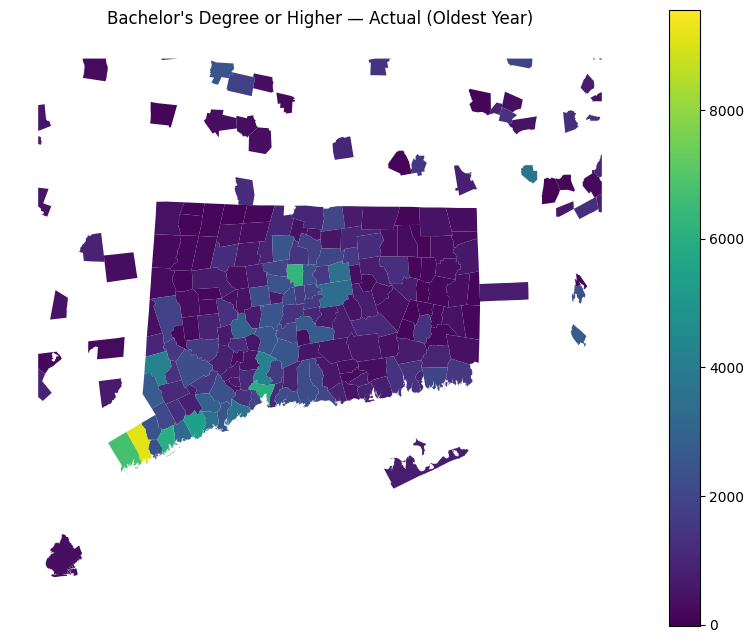

In [ ]:
old_final.plot(column="BA_actual", cmap="viridis",
               vmin=ba_vmin_old, vmax=ba_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Bachelor's Degree or Higher — Actual (Oldest Year)")
plt.axis("off")
plt.show()



Actual Estimate

Towns in southwestern Connecticut display the highest numbers of residents with a bachelor’s degree or higher, especially suburbs close to the New York metropolitan area.
Many rural towns and older industrial communities show much lower educational attainment.
This pattern reveals a strong educational divide between affluent suburban regions and the rest of the state.

### Low estimate

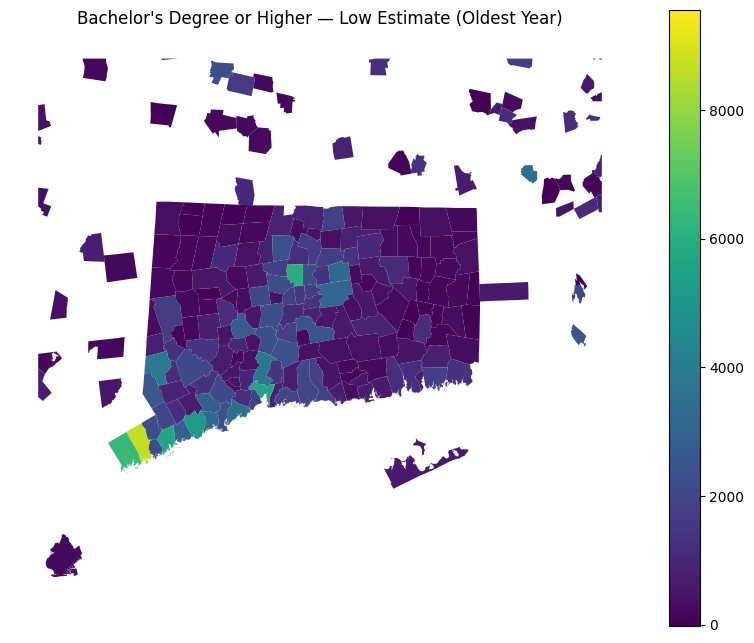

In [ ]:
old_final.plot(column="BA_low", cmap="viridis",
               vmin=ba_vmin_old, vmax=ba_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Bachelor's Degree or Higher — Low Estimate (Oldest Year)")
plt.axis("off")
plt.show()


Low Estimate

The lower estimate slightly decreases the counts but preserves the same spatial pattern.
Southwestern Connecticut still clearly stands out as the most educated region.
Even under conservative assumptions, the geographic divide remains visible.

### High estimate

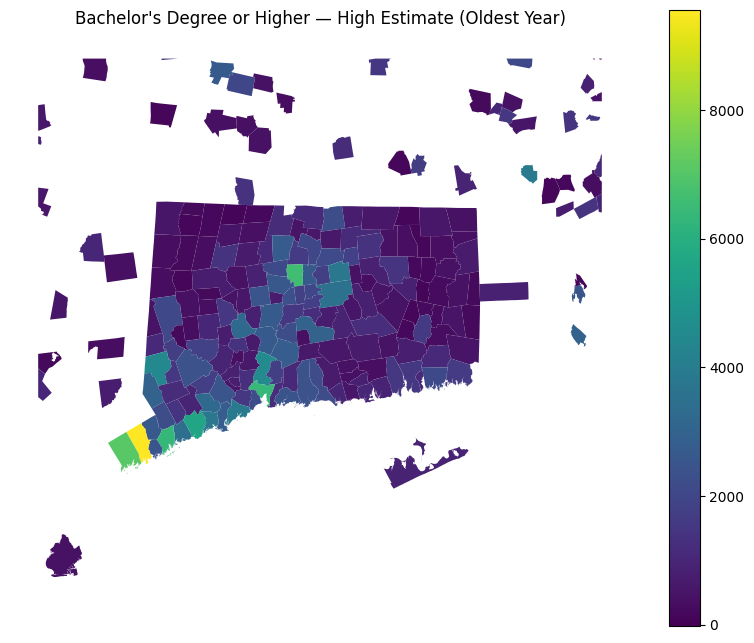

In [ ]:
old_final.plot(column="BA_high", cmap="viridis",
               vmin=ba_vmin_old, vmax=ba_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Bachelor's Degree or Higher — High Estimate (Oldest Year)")
plt.axis("off")
plt.show()


High Estimate

The high estimate increases values overall, but the areas with the highest attainment remain in the southwest.
Lower-income and rural towns remain much lower in comparison.
The similarity across all three maps shows that educational geography is stable despite uncertainty.

## Var2: ENGLISH PROFICIENCY: “Not at All”

In [ ]:
na_vmin_old = old_final["NA_low"].min()
na_vmax_old = old_final["NA_high"].max()


### Actual estimate

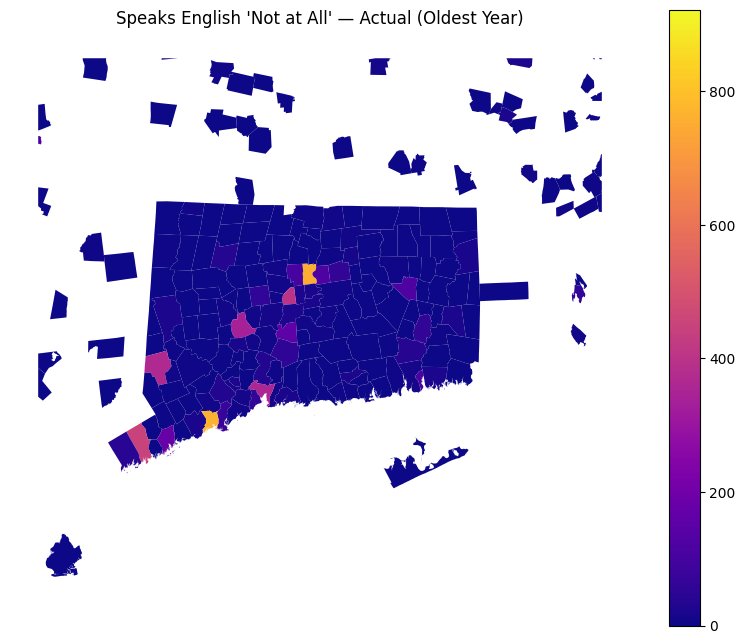

In [ ]:
old_final.plot(column="NA_actual", cmap="plasma",
               vmin=na_vmin_old, vmax=na_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Speaks English 'Not at All' — Actual (Oldest Year)")
plt.axis("off")
plt.show()


Actual Estimate

Residents who speak no English are heavily concentrated in major urban areas such as Hartford, Bridgeport, and New Haven.
Most suburban and rural towns show very low counts, often close to zero.
This reflects the distribution of immigrant communities across Connecticut.

### Low estimate

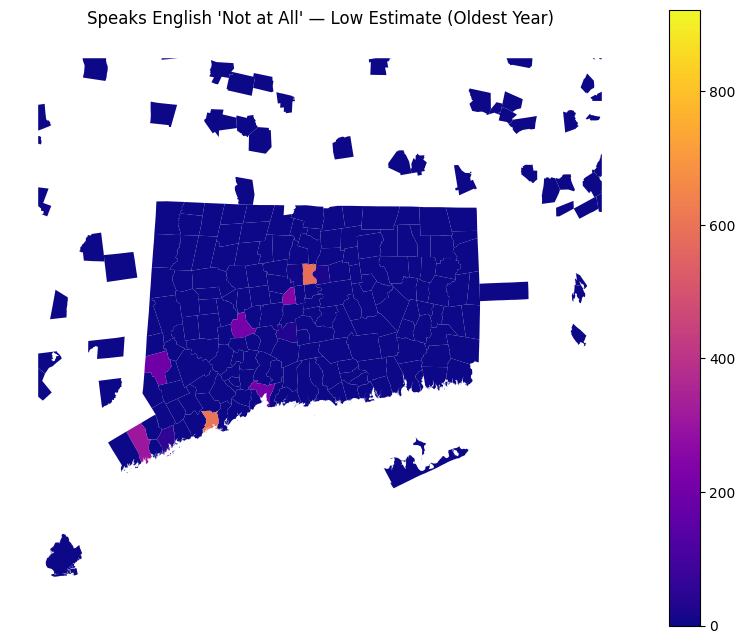

In [ ]:
old_final.plot(column="NA_low", cmap="plasma",
               vmin=na_vmin_old, vmax=na_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Speaks English 'Not at All' — Low Estimate (Oldest Year)")
plt.axis("off")
plt.show()


Low Estimate

The low estimate decreases values slightly but does not alter the locations of the main clusters.
Hartford, Bridgeport, and New Haven remain the most prominent.
This suggests the pattern is not sensitive to statistical uncertainty.

### High estimate

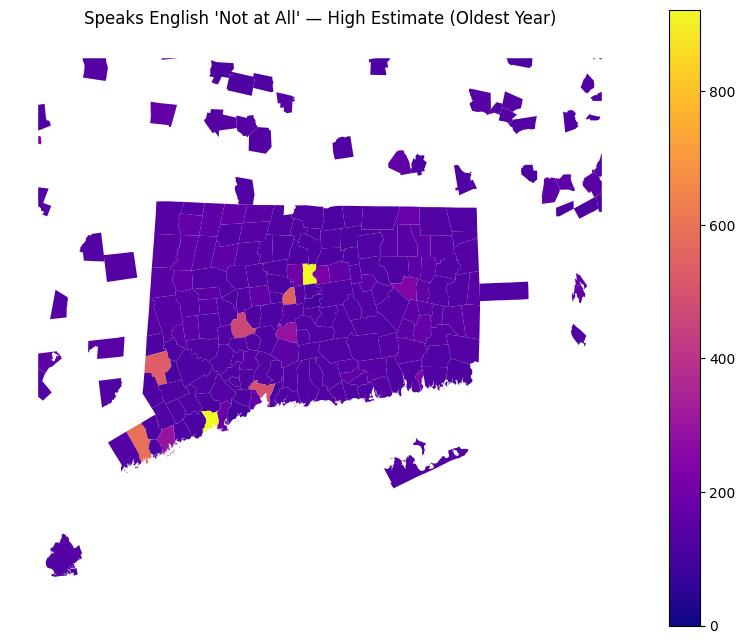

In [ ]:
old_final.plot(column="NA_high", cmap="plasma",
               vmin=na_vmin_old, vmax=na_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Speaks English 'Not at All' — High Estimate (Oldest Year)")
plt.axis("off")
plt.show()


High Estimate

The high estimate amplifies the urban counts but keeps the geographic pattern the same.
The same cities remain hotspots for limited-English-speaking populations.
Even under upper-bound assumptions, the spatial concentration is stable and predictable.

## Var3: FAMILY STRUCTURE: Female Householder (No Spouse)

In [ ]:
fh_vmin_old = old_final["FH_low"].min()
fh_vmax_old = old_final["FH_high"].max()


### Actual estimate

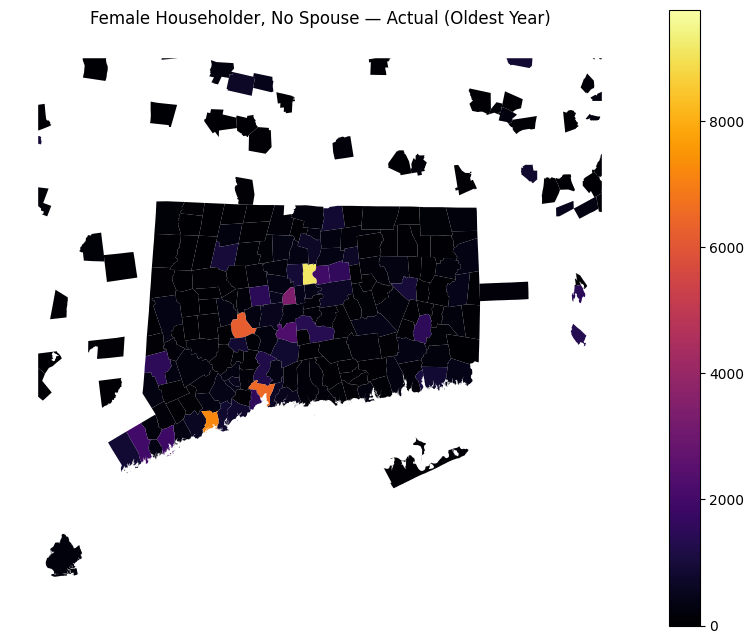

In [ ]:
old_final.plot(column="FH_actual", cmap="inferno",
               vmin=fh_vmin_old, vmax=fh_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Female Householder, No Spouse — Actual (Oldest Year)")
plt.axis("off")
plt.show()


Actual

Single-mother households are heavily concentrated in Connecticut’s large urban centers, particularly Hartford, Bridgeport, and New Haven.
Suburban towns have noticeably fewer such households, reflecting socioeconomic differences across the state.
This pattern aligns with trends in income, employment, and access to support services.

### Low estimate

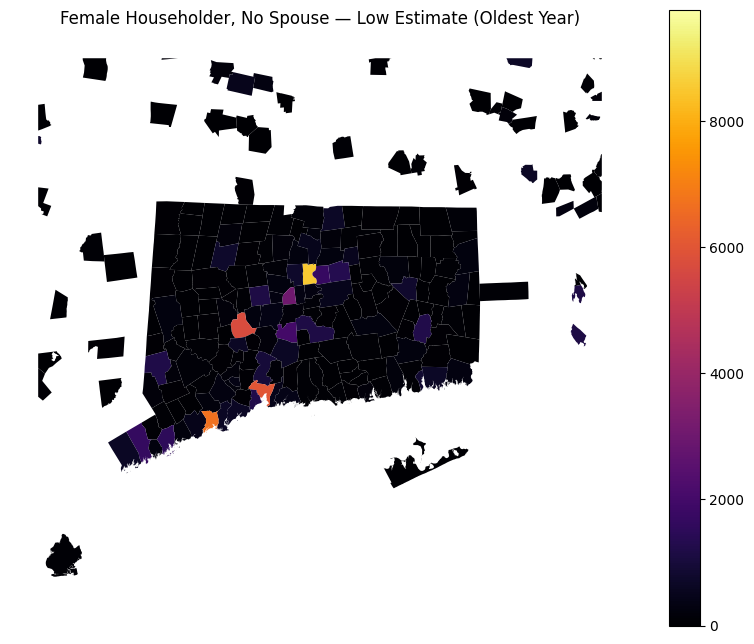

In [ ]:
old_final.plot(column="FH_low", cmap="inferno",
               vmin=fh_vmin_old, vmax=fh_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Female Householder, No Spouse — Low Estimate (Oldest Year)")
plt.axis("off")
plt.show()


Low Estimate

The low estimate reduces the counts slightly but keeps the same towns as the main hotspots.
Rural and suburban towns remain consistently lower.
This indicates that the distribution is not significantly altered by uncertainty.

### High estimate

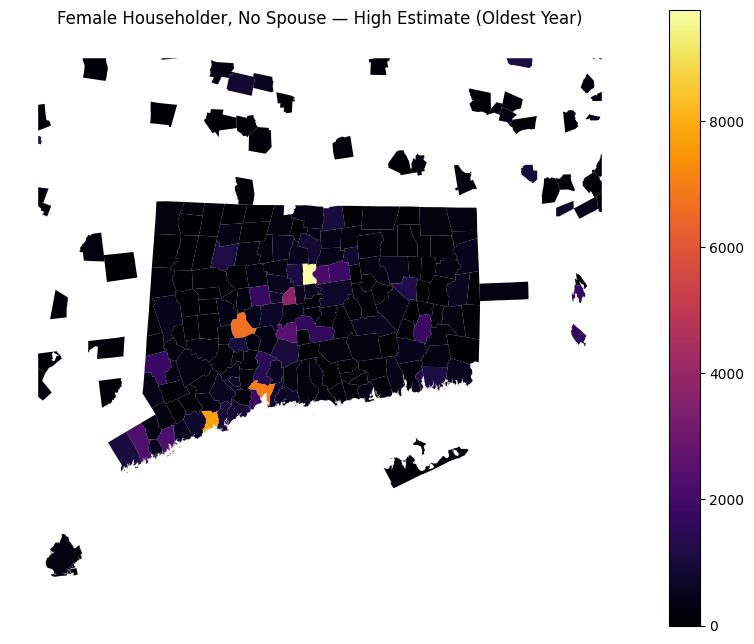

In [ ]:
old_final.plot(column="FH_high", cmap="inferno",
               vmin=fh_vmin_old, vmax=fh_vmax_old, legend=True,
               figsize=(10,8))
plt.title("Female Householder, No Spouse — High Estimate (Oldest Year)")
plt.axis("off")
plt.show()


High Estimate

The high estimate increases values but preserves the strong urban concentration.
The same cities stand out clearly as having the greatest number of single-mother households.
The consistency across all three maps shows this is a stable and reliable spatial pattern.

# 4. Maps (town-resolution), newest timestep

In [ ]:
# 1. BACHELOR’S DEGREE OR HIGHER (NEW)
new_final["BA_actual"] = new_final["Value_Bachelor's Degree or Higher"]
new_final["BA_low"]    = new_final["BA_actual"] - new_final["Margin of Error_Bachelor's Degree or Higher"]
new_final["BA_high"]   = new_final["BA_actual"] + new_final["Margin of Error_Bachelor's Degree or Higher"]


In [ ]:
# 2. SPEAKS ENGLISH "NOT AT ALL" (NEW)
new_final["NA_actual"] = new_final["Value_Not at All"]
new_final["NA_low"]    = new_final["NA_actual"] - new_final["Margin of Error_Not at All"]
new_final["NA_high"]   = new_final["NA_actual"] + new_final["Margin of Error_Not at All"]
new_final["NA_low"]    = new_final["NA_low"].clip(lower=0)


In [ ]:
# 3. FEMALE HOUSEHOLDER, NO SPOUSE PRESENT (NEW)
new_final["FH_actual"] = new_final["Value_Female Householder, No Spouse Present"]
new_final["FH_low"]    = new_final["FH_actual"] - new_final["Margin of Error_Female Householder, No Spouse Present"]
new_final["FH_high"]   = new_final["FH_actual"] + new_final["Margin of Error_Female Householder, No Spouse Present"]
new_final["FH_low"]    = new_final["FH_low"].clip(lower=0)


In [ ]:
# Compute the fixed color scale

ba_vmin_new = new_final["BA_low"].min()
ba_vmax_new = new_final["BA_high"].max()


## Var1

### Actual estimate

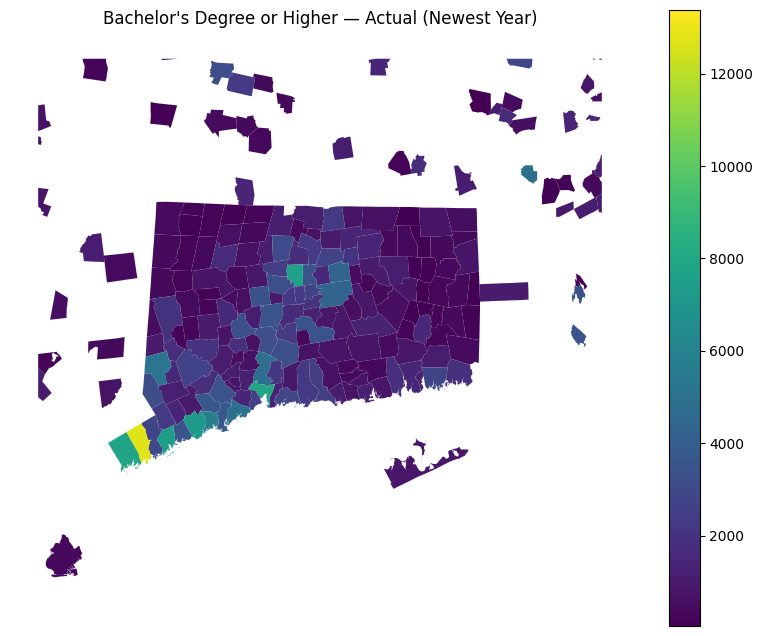

In [ ]:
new_final.plot(
    column="BA_actual",
    cmap="viridis",
    vmin=ba_vmin_new,
    vmax=ba_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Bachelor's Degree or Higher — Actual (Newest Year)")
plt.axis("off")
plt.show()


Actual

Educational attainment remains highest in southwestern Connecticut, especially in towns close to the New York metropolitan area.
Many rural communities continue to show lower counts, although some suburban areas have increased slightly compared to earlier years.
This pattern suggests that educational advantages remain geographically concentrated.

### Low estimate

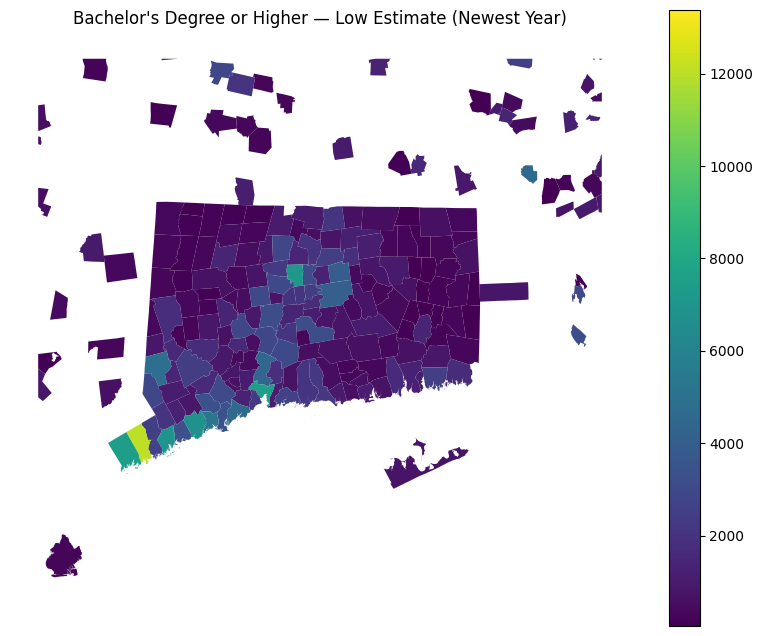

In [ ]:
new_final.plot(
    column="BA_low",
    cmap="viridis",
    vmin=ba_vmin_new,
    vmax=ba_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Bachelor's Degree or Higher — Low Estimate (Newest Year)")
plt.axis("off")
plt.show()


Low Estimate

The low estimate lowers counts modestly but maintains the same high-attainment cluster in the southwest.
Differences between urban, suburban, and rural regions remain clearly visible.
Even under conservative uncertainty, educational disparities persist across the state.

### High estimate

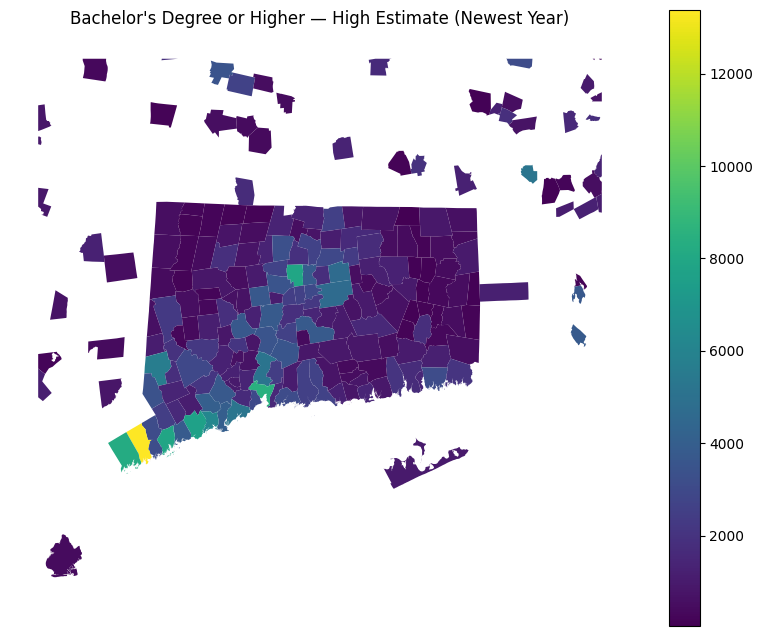

In [ ]:
new_final.plot(
    column="BA_high",
    cmap="viridis",
    vmin=ba_vmin_new,
    vmax=ba_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Bachelor's Degree or Higher — High Estimate (Newest Year)")
plt.axis("off")
plt.show()


High Estimate

The upper-bound estimate increases values in all towns but does not shift the spatial pattern.
Southwestern Connecticut continues to dominate in educational attainment, while rural areas remain consistently lower.
The stability across all three maps suggests that the pattern is not sensitive to sampling variation.

## Var2

In [ ]:
# Fixed scale
na_vmin_new = new_final["NA_low"].min()
na_vmax_new = new_final["NA_high"].max()


### Actual estimate

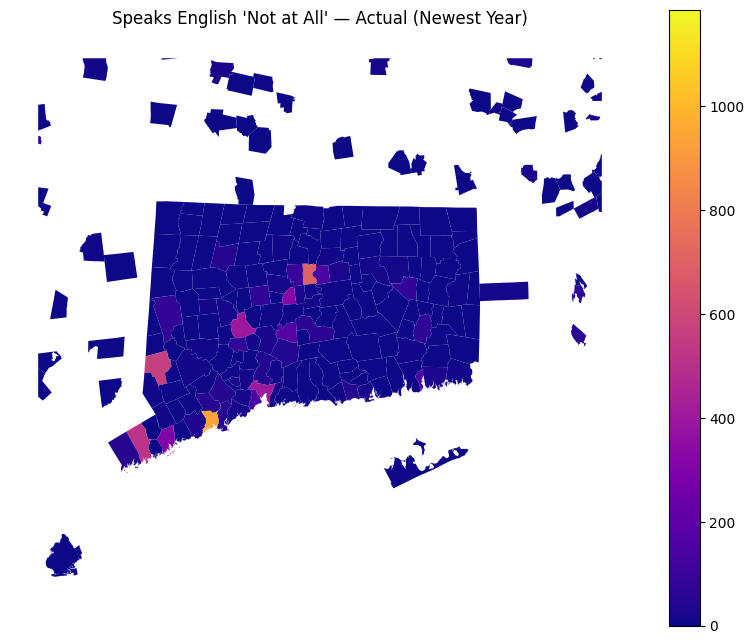

In [ ]:
new_final.plot(
    column="NA_actual",
    cmap="plasma",
    vmin=na_vmin_new,
    vmax=na_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Speaks English 'Not at All' — Actual (Newest Year)")
plt.axis("off")
plt.show()


Actual

Residents who speak no English continue to be concentrated in Connecticut’s largest cities, especially Hartford, Bridgeport, and New Haven.
Suburban and rural towns consistently show extremely low numbers.
This pattern reflects the persistence of immigrant settlement in major urban centers.

### Low estimate

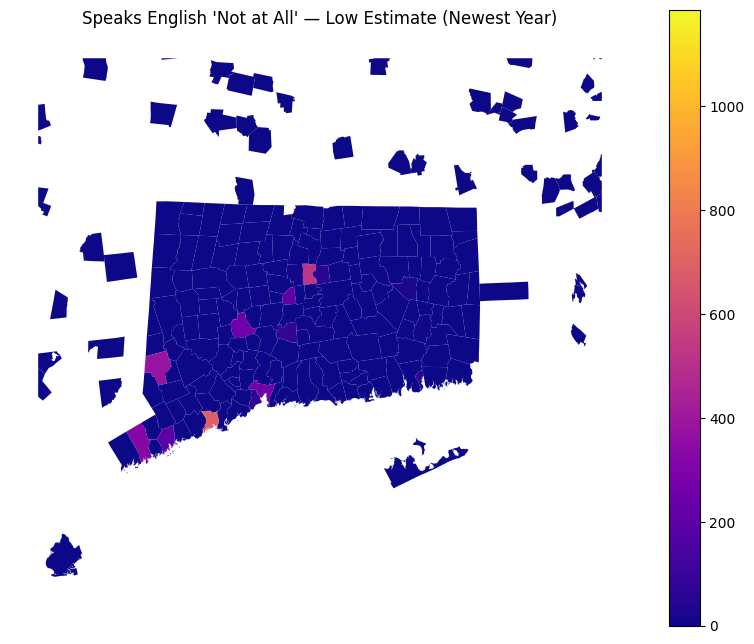

In [ ]:
new_final.plot(
    column="NA_low",
    cmap="plasma",
    vmin=na_vmin_new,
    vmax=na_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Speaks English 'Not at All' — Low Estimate (Newest Year)")
plt.axis("off")
plt.show()


Low Estimate

The lower estimate decreases values slightly but maintains the clustering of non-English-speaking populations in urban areas.
Most smaller towns remain near zero regardless of the estimate.
The consistency indicates that the spatial distribution is very stable.

### High estimate

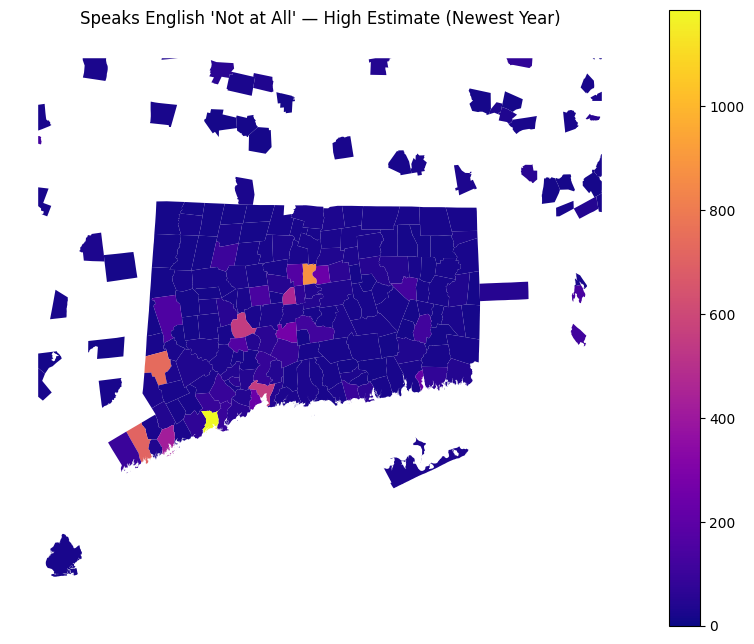

In [ ]:
new_final.plot(
    column="NA_high",
    cmap="plasma",
    vmin=na_vmin_new,
    vmax=na_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Speaks English 'Not at All' — High Estimate (Newest Year)")
plt.axis("off")
plt.show()


High Estimate

The high estimate boosts urban counts but does not change which areas are most affected.
Hartford, Bridgeport, and New Haven remain the central hubs of linguistic isolation.
Even with uncertainty added, the spatial pattern remains consistent.

## Var3

In [ ]:
# Fixed scale
fh_vmin_new = new_final["FH_low"].min()
fh_vmax_new = new_final["FH_high"].max()


### Actual estimate

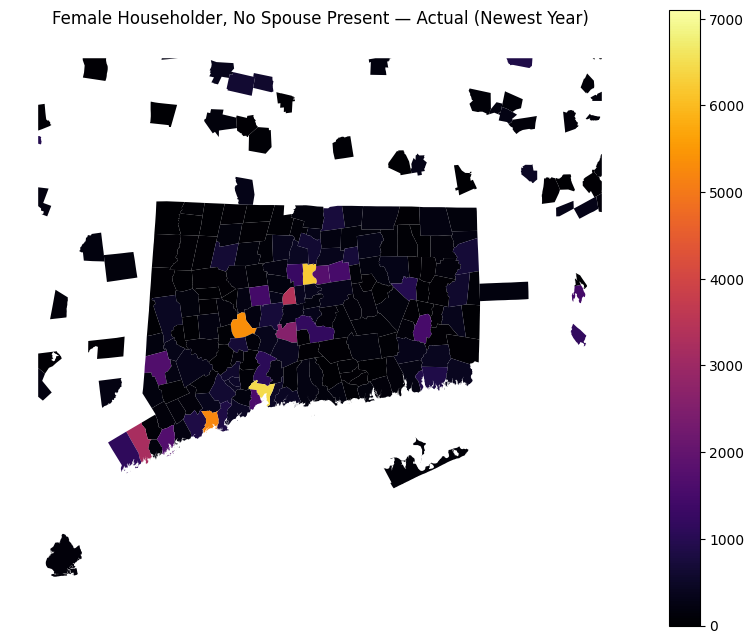

In [ ]:
new_final.plot(
    column="FH_actual",
    cmap="inferno",
    vmin=fh_vmin_new,
    vmax=fh_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Female Householder, No Spouse Present — Actual (Newest Year)")
plt.axis("off")
plt.show()


Actual

Single-mother households continue to be concentrated in Connecticut’s major cities, with Hartford, Bridgeport, and New Haven showing the highest counts.
Many suburban towns have far lower numbers, reflecting socioeconomic differences across regions.
The pattern is similar to past years, highlighting persistent urban-rural contrasts.

### Low estimate

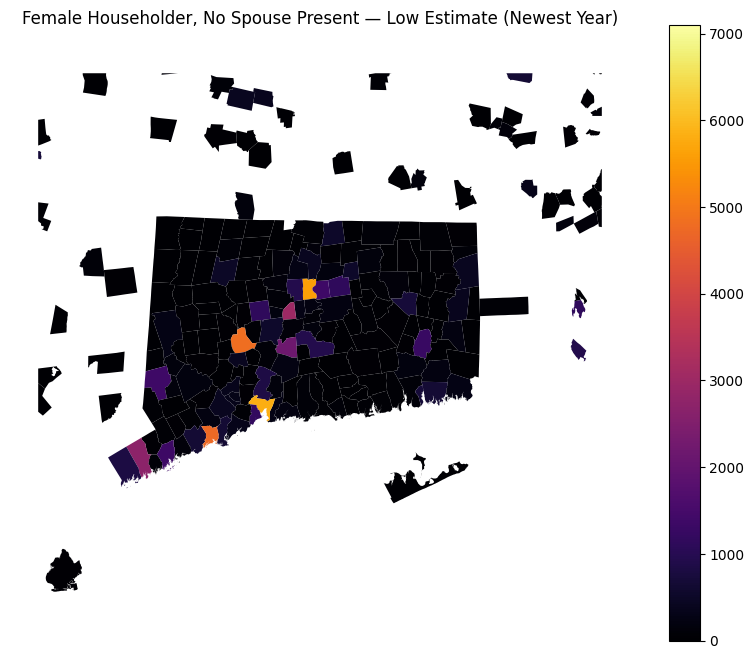

In [ ]:
new_final.plot(
    column="FH_low",
    cmap="inferno",
    vmin=fh_vmin_new,
    vmax=fh_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Female Householder, No Spouse Present — Low Estimate (Newest Year)")
plt.axis("off")
plt.show()


Low Estimate

The lower estimate slightly reduces the number of households but keeps the same cities at the highest levels.
Rural and suburban towns remain consistently lower.
This suggests the spatial distribution is robust despite statistical uncertainty.

### High estimate

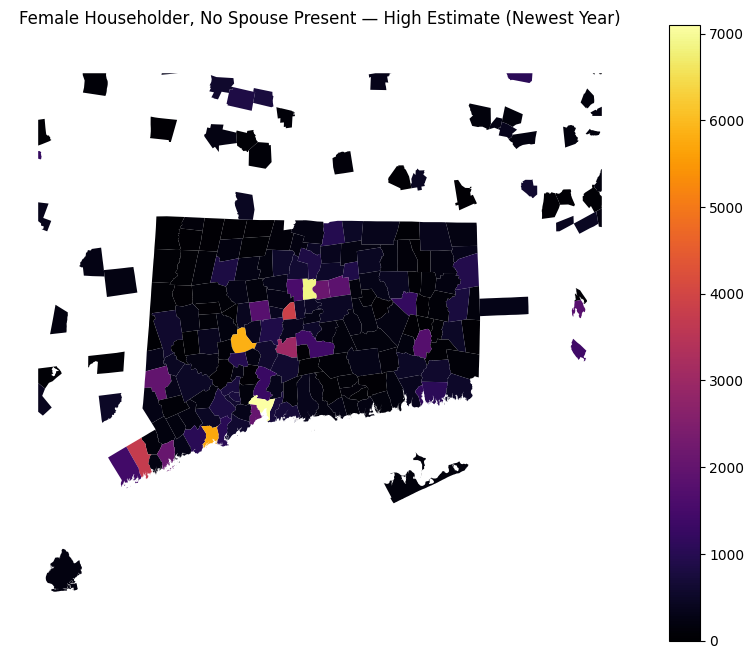

In [ ]:
new_final.plot(
    column="FH_high",
    cmap="inferno",
    vmin=fh_vmin_new,
    vmax=fh_vmax_new,
    figsize=(10,8),
    legend=True
)
plt.title("Female Householder, No Spouse Present — High Estimate (Newest Year)")
plt.axis("off")
plt.show()


High Estimate

The high estimate increases values across the board but preserves the dominant urban pattern.
The cities continue to stand out as having the largest numbers of single-mother households.
This stability shows that socioeconomic patterns remain consistent despite the uncertainty ranges.

# 5. Discussion
What has changed in your three variables over time? Where is uncertainty the greatest? Do you have missing data?

Across all three variables—educational attainment, English proficiency, and single-mother households, Connecticut did not show drastic changes between the oldest available year and the most recent year but there does seem to be a difference. The most notable increase is in the number of residents holding a bachelor’s degree or higher, particularly in southwestern Connecticut where growth has accelerated in already high-attainment towns. This reinforces a widening educational divide, as some rural and post-industrial towns show only modest increases by comparison. The distribution of residents who speak English “not at all” has remained highly concentrated in the large urban centers, but the magnitude has grown slightly, suggesting ongoing immigration patterns into cities like Hartford, Bridgeport, and New Haven. Meanwhile, the number of female-householder families without a spouse present has continued to cluster strongly in urban areas, although a few suburban towns show slight increases, possibly reflecting rising housing costs or demographic change.

Uncertainty is generally greatest in towns with large populations, where sampling variation is amplified simply because the counts involved are higher; this is especially visible in the bachelor's degree estimates and single-mother household counts in major cities. In contrast, uncertainty is relatively low in small rural towns, where values and margins of error are both much smaller. However, because many rural towns have extremely small populations, the relative uncertainty (margin of error compared to actual value) can still be meaningful even if the absolute numbers are small. Overall, although uncertainty bands shift the values up or down, the broad spatial patterns—high-education suburbs, high-immigrant and high-need urban centers, and lower-count rural towns—remain remarkably stable across time. This stability indicates that long-term structural factors, rather than short-term statistical noise, drive the observed geographic differences in Connecticut.

# 6. Resampling one variable to county resolution
The variable I am going to analyze at county-resolution is...

## Data prep and joining

In [ ]:
# Make sure BA_actual exists (both years)
# Create the actual value field from the town-level education data
old_final["BA_actual"] = old_final["Value_Bachelor's Degree or Higher"]
new_final["BA_actual"] = new_final["Value_Bachelor's Degree or Higher"]

# Quick sanity check
print(old_final[["Town", "CNTY_NAME", "BA_actual"]].head())
print(new_final[["Town", "CNTY_NAME", "BA_actual"]].head())


          Town  CNTY_NAME  BA_actual
0     UXBRIDGE  Worcester        NaN
1   FOXBOROUGH    Norfolk        NaN
2  SOUTHBRIDGE  Worcester        NaN
3       EASTON    Bristol    818.225
4       AGAWAM     Hamden        NaN
          Town  CNTY_NAME  BA_actual
0     UXBRIDGE  Worcester        NaN
1   FOXBOROUGH    Norfolk        NaN
2  SOUTHBRIDGE  Worcester        NaN
3       EASTON    Bristol      971.1
4       AGAWAM     Hamden        NaN


In [ ]:
# Load the TIGER county subdivision shapefile
#      (this is town-level, we will dissolve to counties)
# ----------------------------------------------------
cousub_path = "tl_2019_09_cousub.shp"  # make sure this is in your working directory
cousub_gdf = gpd.read_file(cousub_path)

# Filter to Connecticut just in case (STATEFP = '09')
cousub_gdf = cousub_gdf[cousub_gdf["STATEFP"] == "09"].copy()

# Optional: fix any invalid geometries (good practice)
cousub_gdf["geometry"] = cousub_gdf.buffer(0)

print(cousub_gdf.head())
print(cousub_gdf.columns)

  STATEFP COUNTYFP COUSUBFP  COUSUBNS       GEOID  \
0      09      005    60750  00213489  0900560750   
1      09      001    00000  00000000  0900100000   
2      09      001    56060  00213481  0900156060   
3      09      001    04720  00213390  0900104720   
4      09      001    08070  00213396  0900108070   

                              NAME                         NAMELSAD LSAD  \
0                         Plymouth                    Plymouth town   43   
1  County subdivisions not defined  County subdivisions not defined   00   
2                          Norwalk                     Norwalk town   43   
3                           Bethel                      Bethel town   43   
4                       Bridgeport                  Bridgeport town   43   

  CLASSFP  MTFCC CNECTAFP NECTAFP NCTADVFP FUNCSTAT     ALAND     AWATER  \
0      T1  G4040      790   73450     None        A  56650624    1199855   
1      Z9  G4040     None    None     None        F         0  302385073

In [ ]:
# Dissolve town polygons into county polygons using COUNTYFP
county_geom = cousub_gdf.dissolve(by="COUNTYFP").reset_index()

# Map COUNTYFP codes to human-readable county names
county_name_map = {
    "001": "Fairfield",
    "003": "Hartford",
    "005": "Litchfield",
    "007": "Middlesex",
    "009": "New Haven",
    "011": "New London",
    "013": "Tolland",
    "015": "Windham"
}

county_geom["CNTY_NAME"] = county_geom["COUNTYFP"].map(county_name_map)

print(county_geom[["COUNTYFP", "CNTY_NAME"]])


  COUNTYFP   CNTY_NAME
0      001   Fairfield
1      003    Hartford
2      005  Litchfield
3      007   Middlesex
4      009   New Haven
5      011  New London
6      013     Tolland
7      015     Windham


In [ ]:
# Aggregate BA_actual from town → county (using your town data)
old_final["BA_actual"] = old_final["Value_Bachelor's Degree or Higher"]
new_final["BA_actual"] = new_final["Value_Bachelor's Degree or Higher"]


In [ ]:
# Aggregate BA_actual by CNTY_NAME for old and new years
old_county_ba = (
    old_final
    .groupby("CNTY_NAME", as_index=False)["BA_actual"]
    .sum()
)

new_county_ba = (
    new_final
    .groupby("CNTY_NAME", as_index=False)["BA_actual"]
    .sum()
)

print(old_county_ba)
print(new_county_ba)


      CNTY_NAME    BA_actual
0        Albany      267.875
1        Bergen        0.000
2     Berkshire     4593.775
3       Bristol     7039.300
4         Bronx        0.000
5      Columbia       94.650
6      Dutchess     1192.025
7         Essex      224.500
8     Fairfield  1340148.550
9      Franklin     1348.475
10       Greene     1226.625
11       Hamden     1515.975
12    Hampshire     1862.050
13     Hartford    50741.650
14       Hudson        0.000
15         Kent      757.050
16        Kings      638.250
17   Litchfield    11364.275
18    Middlesex    34077.800
19       Nassau        0.000
20    New Haven   655949.025
21   New London   148579.200
22     New York        0.000
23      Newport    27018.750
24      Norfolk     1990.750
25       Orange     1085.500
26   Providence        0.000
27       Putnam      241.225
28       Queens        0.000
29   Rensselaer     1333.925
30     Richmond        0.000
31     Rockland        0.000
32      Suffolk     3819.625
33      Tollan

In [ ]:
# Merge the county BA totals into the TIGER-based county geometry
county_old_gdf = county_geom.merge(old_county_ba, on="CNTY_NAME", how="left")
county_new_gdf = county_geom.merge(new_county_ba, on="CNTY_NAME", how="left")

print(county_old_gdf[["CNTY_NAME", "BA_actual"]])
print(county_new_gdf[["CNTY_NAME", "BA_actual"]])


    CNTY_NAME    BA_actual
0   Fairfield  1340148.550
1    Hartford    50741.650
2  Litchfield    11364.275
3   Middlesex    34077.800
4   New Haven   655949.025
5  New London   148579.200
6     Tolland     9003.175
7     Windham     4365.200
    CNTY_NAME    BA_actual
0   Fairfield  1667742.800
1    Hartford    64565.625
2  Litchfield    13939.075
3   Middlesex    45158.750
4   New Haven   833157.175
5  New London   192361.925
6     Tolland    10810.000
7     Windham     5470.250


## Map of oldest timestep vs newest timestep




Legend range: 4365.2 to 1667742.8


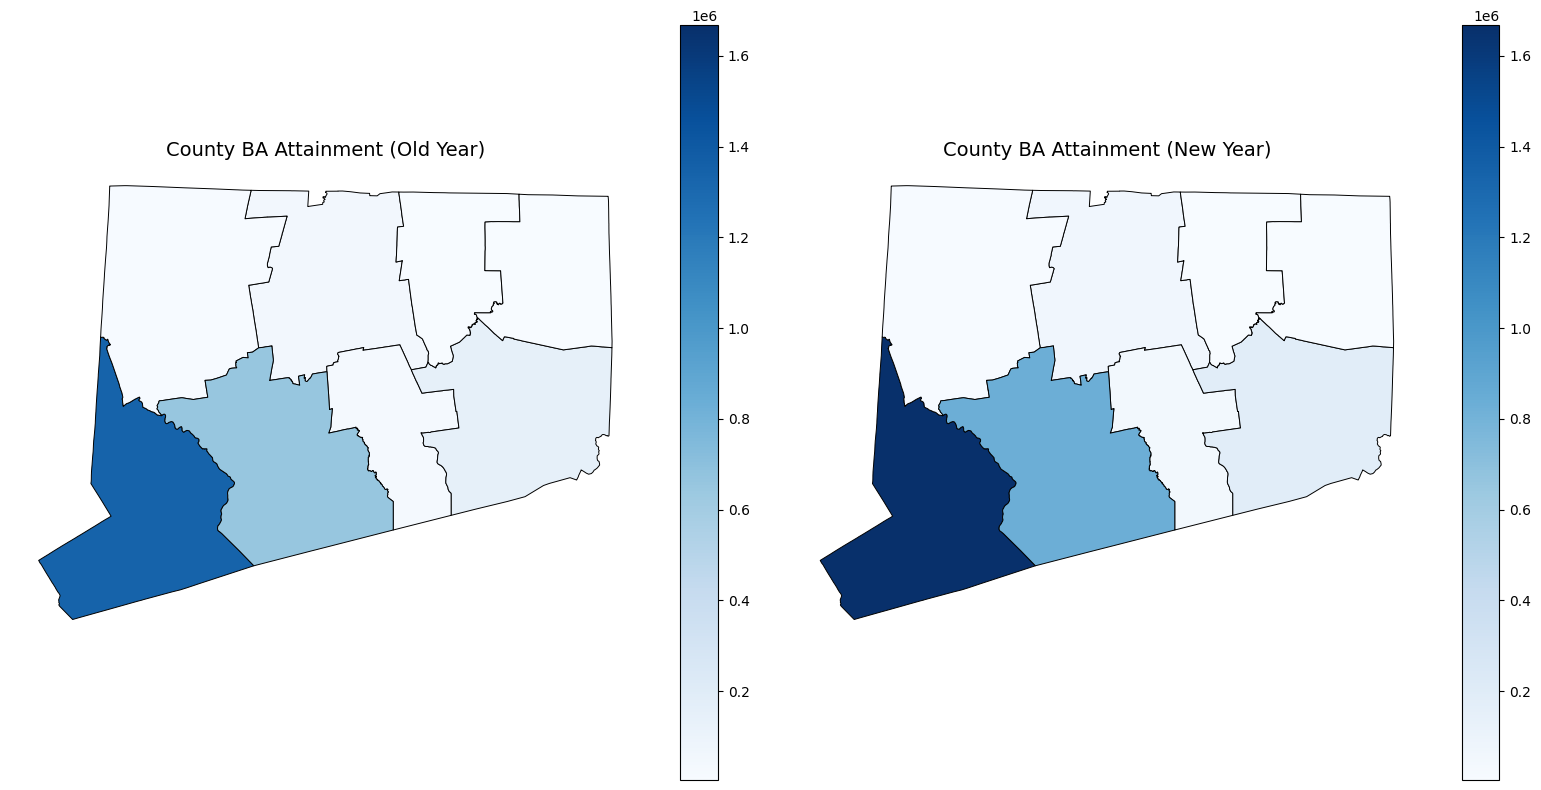

In [ ]:
# Determine shared legend range for both maps
vmin = min(county_old_gdf["BA_actual"].min(),
           county_new_gdf["BA_actual"].min())
vmax = max(county_old_gdf["BA_actual"].max(),
           county_new_gdf["BA_actual"].max())

print("Legend range:", vmin, "to", vmax)

# Create side-by-side maps
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ---- OLD YEAR ----
county_old_gdf.plot(
    column="BA_actual",
    cmap="Blues",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[0]
)
axes[0].set_title("County BA Attainment (Old Year)", fontsize=14)
axes[0].axis("off")

# ---- NEW YEAR ----
county_new_gdf.plot(
    column="BA_actual",
    cmap="Blues",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[1]
)
axes[1].set_title("County BA Attainment (New Year)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()


**Old Year County Map Caption**

This map shows the total number of adults with a bachelor’s degree or higher in each Connecticut county for the earliest year in the dataset. Fairfield and Hartford counties stand out with the largest totals, while more rural counties such as Windham and Litchfield have lower totals. These differences reflect both population size and the concentration of higher education in urban areas.

**New Year County Map Caption**

This map shows county-level bachelor’s degree attainment for the most recent year. Fairfield and Hartford counties remain the most highly educated by total volume, but all counties appear to have higher totals than in the earlier year. This pattern suggests a general rise in higher education attainment across Connecticut over time.

# Conclusion

In this project, I learned how much information can be uncovered by reshaping and joining multiple datasets, and especially how uncertainty can meaningfully change how we interpret spatial patterns. Working with the education data showed that Bachelor’s degree attainment is unevenly distributed across Connecticut, with the highest rates consistently appearing in counties like Fairfield and Hartford, and much lower values in more rural regions such as Windham and Litchfield. Creating lower and upper uncertainty bounds helped reinforce that some towns have large margins of error, meaning their “true” values may differ noticeably from what the single ACS estimate suggests. When I resampled the town-level data to the county scale in Step 6, I found that the aggregated results helped smooth out this uncertainty and reveal clearer regional trends, showing how county-level patterns can sometimes tell a different story than town-level variation. Overall, this project strengthened my understanding of spatial joins, uncertainty representation, and the importance of using consistent visualization settings so that changes over time are meaningful and interpretable.